In [1]:
# Project data exploration
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
#scanpy workflow via
#https://nbisweden.github.io/workshop-scRNAseq/archive/2025/labs/scanpy/scanpy_01_qc.html

In [2]:
#import packages 
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.sparse as sp
import h5py
import anndata as ad
from gtfparse import read_gtf

In [3]:
#Package versions
import importlib
print("Package versions:")
for package_name in ["numpy", "pandas", "scanpy", "matplotlib", "seaborn", "scipy", "anndata", "harmonypy"]:
    print(f"- {package_name}: {importlib.metadata.version(package_name)}")

Package versions:
- numpy: 2.4.6
- pandas: 2.3.3
- scanpy: 1.12.1
- matplotlib: 3.10.9
- seaborn: 0.13.2
- scipy: 1.17.1
- anndata: 0.12.16
- harmonypy: 2.0.0


In [19]:
#Load the data
data_dir = "../data/frangieh"
adata = sc.read_h5ad(f"{data_dir}/rna.h5ad")

In [5]:
#Print the data
print(adata)

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'


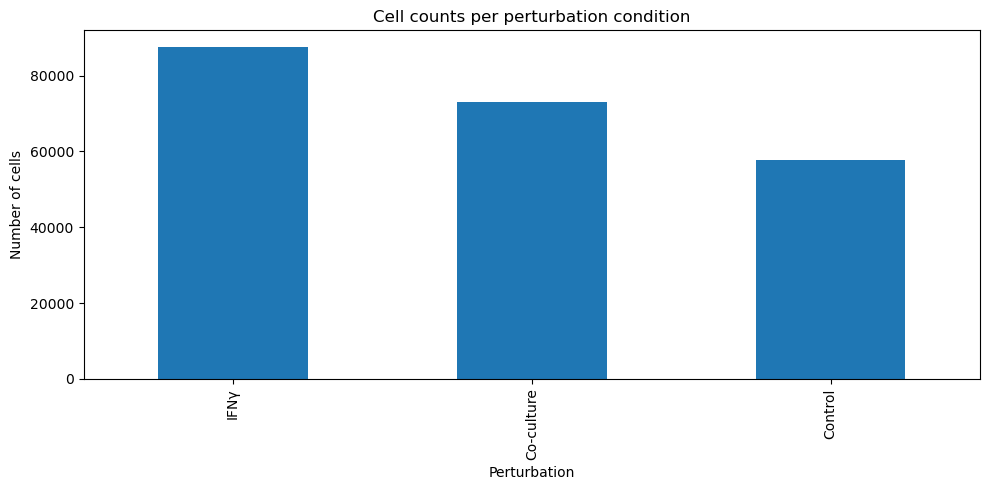

In [6]:
# Explore the columns 
#perturbation_2 represents the condition
# Count cells per perturbation
counts = adata.obs["perturbation_2"].value_counts()
# Plot
plt.figure(figsize=(10, 5))
counts.plot(kind="bar")
plt.xlabel("Perturbation")
plt.ylabel("Number of cells")
plt.title("Cell counts per perturbation condition")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [7]:
# Data exploration
adata.shape
# 218 331 cells, 23712 genes
# Cell numbers across 3 conditions
cell_counts = adata.obs["perturbation_2"].value_counts().sort_index()
for perturbation, count in cell_counts.items():
    print(f"{perturbation}: {count} cells")

Co-culture: 73114 cells
Control: 57627 cells
IFNγ: 87590 cells


In [22]:
# QC steps via scanpy workflow
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [23]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

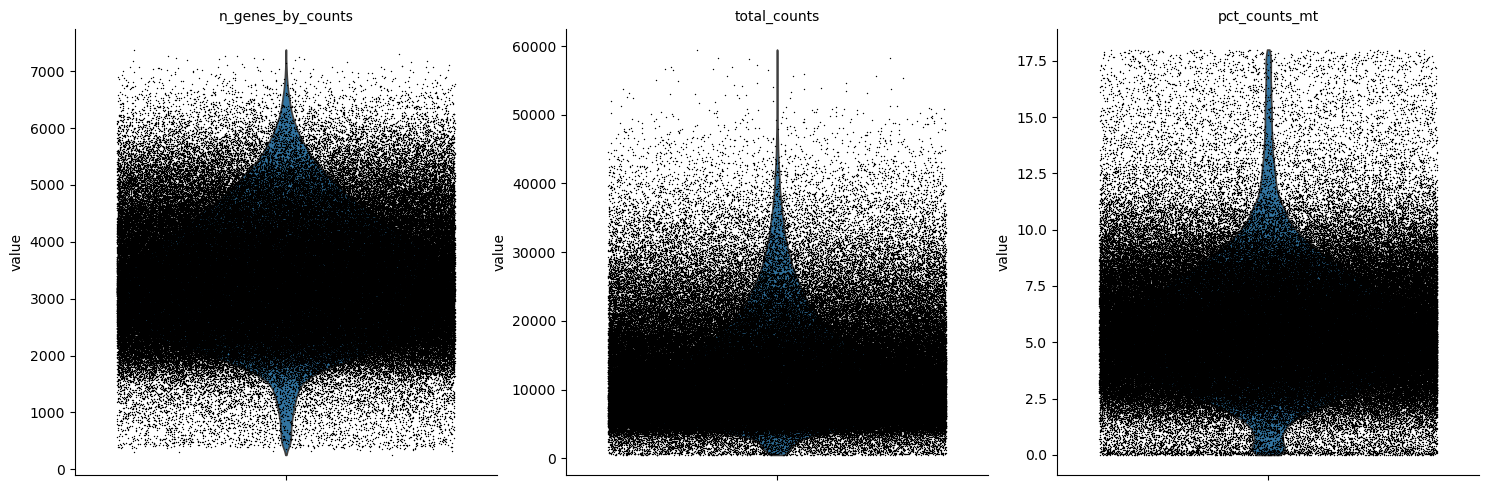

In [24]:
#Violin plots for qc values
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [25]:
# n_genes_by_counts 6500
#total_counts 40 000
#pct_counts_mt 15% because of death cells 

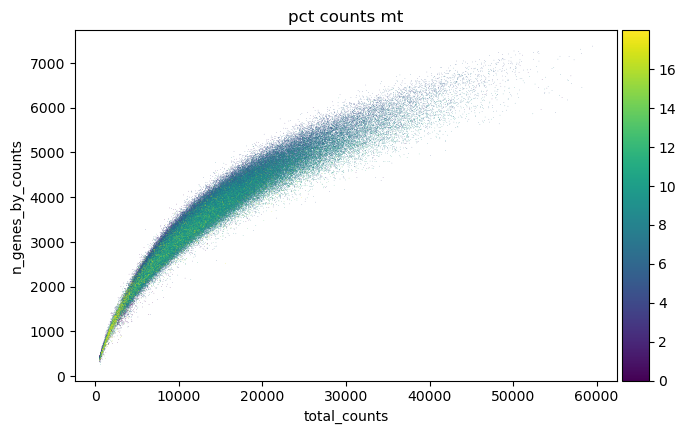

In [26]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [27]:
#Filter cells out that express less then 100 genes and genes that are expressed less then 3 cells
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

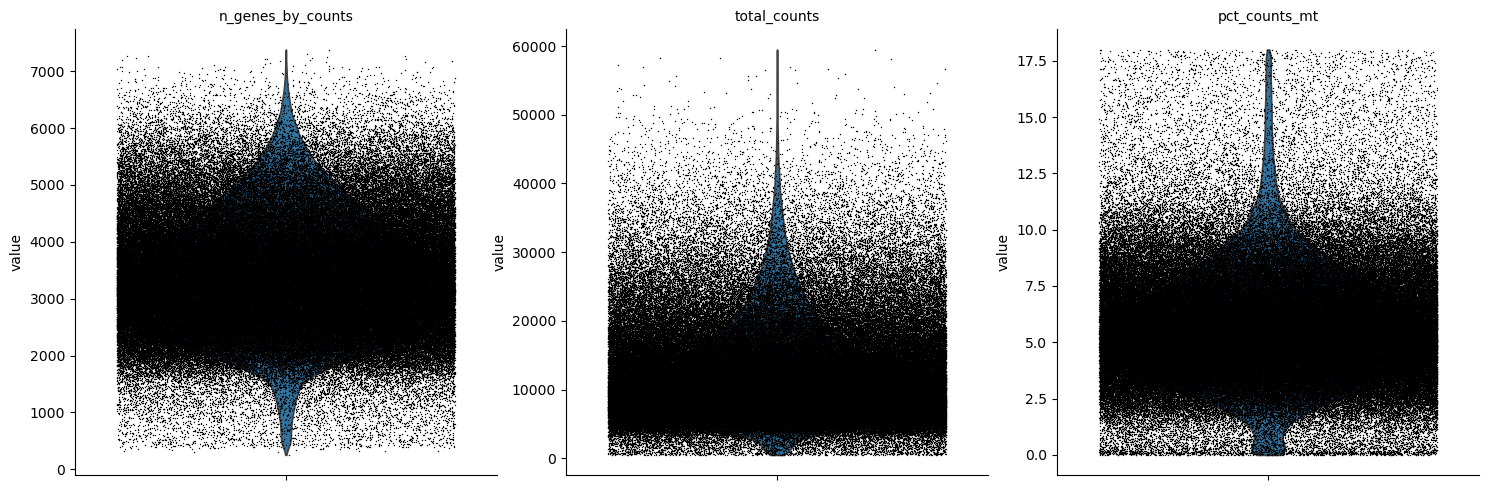

In [28]:
# Visualize after filtering the cells and the genes
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [29]:
# Shape of adata after filtering
adata.shape
# 218331 cells and 23711 genes

(218331, 23711)

In [37]:
#Remove cells with high mitochondrial counts
adata = adata[adata.obs.pct_counts_mt < 15]

In [38]:
adata.shape # 216159, 23711

(216159, 23711)

In [39]:
# save the data after mito filtering and cell an genes filtering
adata_qc_1 = adata.copy()
adata_qc_1 = adata.write("../data/frangieh/adata_qc1.h5ad")

In [40]:
adata = sc.read_h5ad("../data/frangieh/adata_qc1.h5ad")

In [41]:
adata = adata[adata.obs.total_counts < 40000]

In [42]:
adata.shape # 215 364 cells 23711 genes

(215364, 23711)

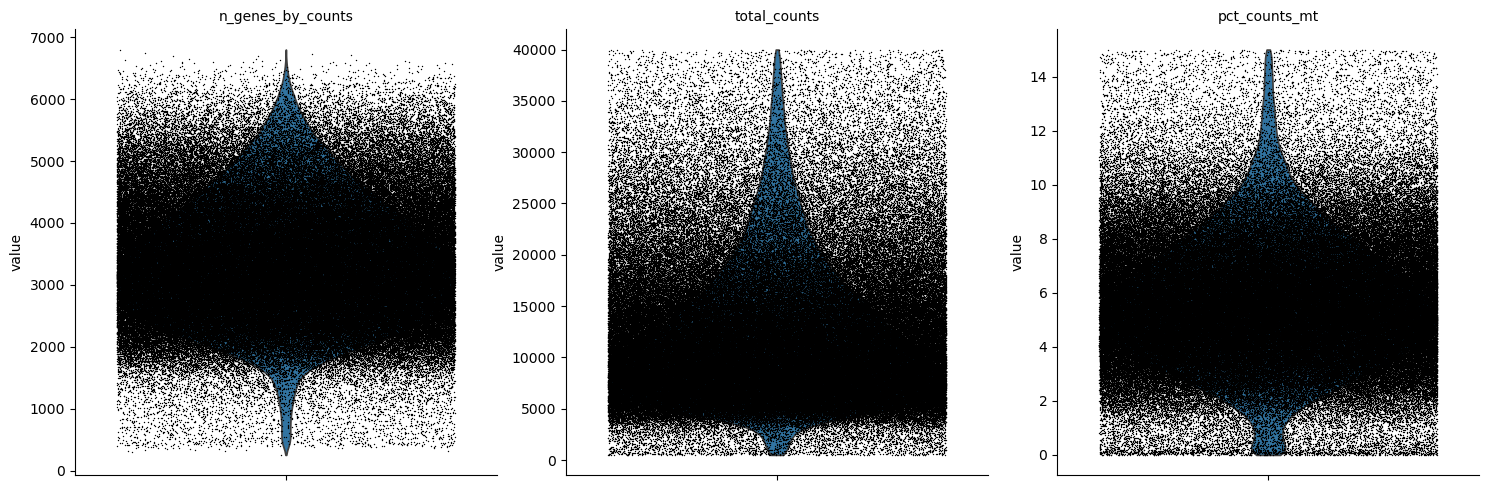

In [43]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [44]:
#Remove the too low genes by counts
sc.pp.filter_cells(adata, min_counts=200)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:160: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


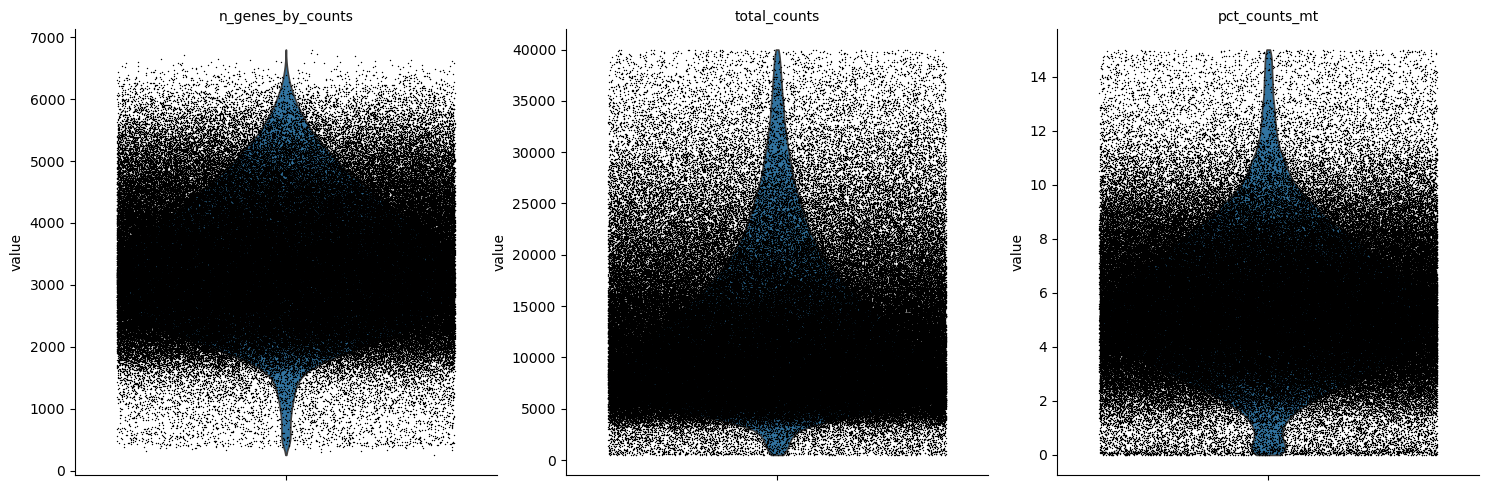

In [45]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [46]:
adata.shape #215364

(215364, 23711)

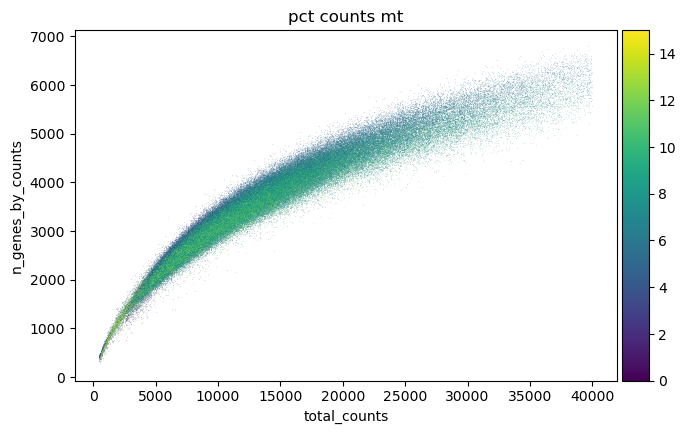

In [47]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [5]:
# Save the data
adata_qc = adata.copy()
adata_qc = adata.write("../data/frangieh/adata_qc.h5ad")

In [3]:
# Predicted Doublet detection
import scanpy as sc 

In [4]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_qc.h5ad")

In [5]:
# split per batch into new objects.
import scrublet as scr
import pandas as pd
import scipy.sparse as sp

batches = adata.obs["perturbation_2"].cat.categories.tolist()
alldata = {}

for batch in batches:
    tmp = adata[adata.obs["perturbation_2"] == batch].copy()
    print(batch, ":", tmp.shape[0], "cells")

    # Use raw counts
    X = tmp.raw.X if tmp.raw is not None else tmp.X

    scrub = scr.Scrublet(X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(
        verbose=False,
        n_prin_comps=20
    )

    alldata[batch] = pd.DataFrame(
        {
            "doublet_score": doublet_scores,
            "predicted_doublets": predicted_doublets
        },
        index=tmp.obs.index
    )

    print(predicted_doublets.sum(), "predicted doublets")

Co-culture : 71959 cells
4866 predicted doublets
Control : 56425 cells
6530 predicted doublets
IFNγ : 86980 cells
12794 predicted doublets


In [6]:
# Co-culture : 71959 cells and 4866 predicted doublets
#Control: 56425 cells and 6530 predicted doublets
#IFN gamma 86980 cells and 12794
#Too many predicted doublets in IFN gamma cultured batch 

In [7]:
# add predictions to the adata object.
scrub_pred = pd.concat(alldata.values())
adata.obs['doublet_scores'] = scrub_pred['doublet_score'] 
adata.obs['predicted_doublets'] = scrub_pred['predicted_doublets'] 

sum(adata.obs['predicted_doublets'])

24190

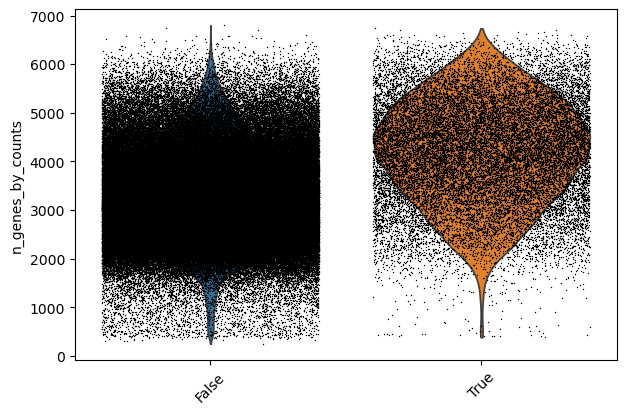

In [8]:
# add in column with singlet/doublet instead of True/False
%matplotlib inline

adata.obs['doublet_info'] = adata.obs["predicted_doublets"].astype(str)
sc.pl.violin(adata, 'n_genes_by_counts', jitter=0.4, groupby = 'doublet_info', rotation=45)

In [10]:
# save the data with the objects predicted doublets
adata_qc_pd = adata.copy()
adata_qc_pd = adata.write("../data/frangieh/adata_pd.h5ad")

In [11]:
# Remove the predicted doublets 
adata = sc.read_h5ad("../data/frangieh/adata_pd.h5ad")

In [12]:
print(adata)
print(adata.layers.keys())

AnnData object with n_obs × n_vars = 215364 × 23711
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_cou

In [16]:
# remove the predicted doublets if important regarding the visualization above 
adata = adata[adata.obs['doublet_info'] == 'False',:]
print(adata.shape)

(191174, 23711)


In [17]:
adata.shape

(191174, 23711)

In [19]:
adata_qc_done = adata.copy()
adata_qc_done = adata.write_h5ad("../data/frangieh/adata_qc_done")

In [20]:
# Load the qc done data
import scanpy as sc
adata = sc.read_h5ad("../data/frangieh/adata_qc_done")

In [21]:
adata.layers["counts"] = adata.X.copy()

In [22]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

In [23]:
# Highly dynamical genes
#Total genes 23711
sc.pp.highly_variable_genes(adata, n_top_genes=10000)

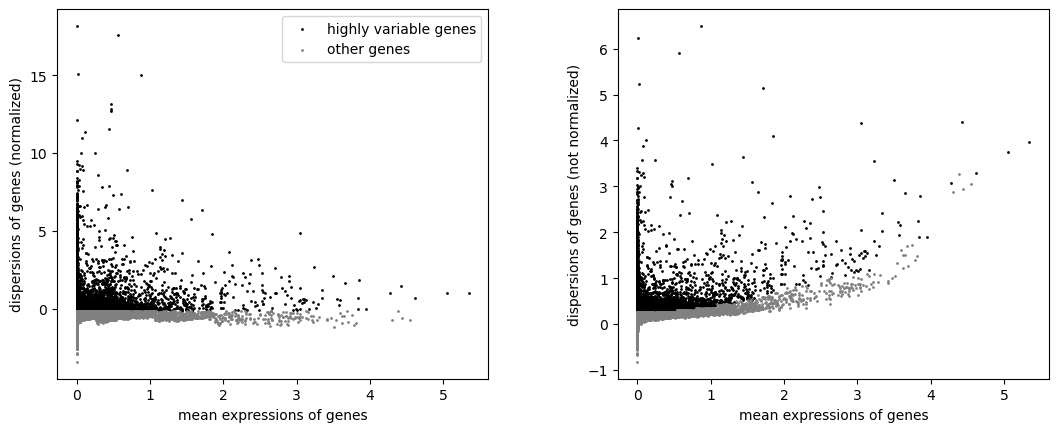

In [24]:
sc.pl.highly_variable_genes(adata)

In [26]:
#Dimensionality reduction PCA
sc.tl.pca(adata)

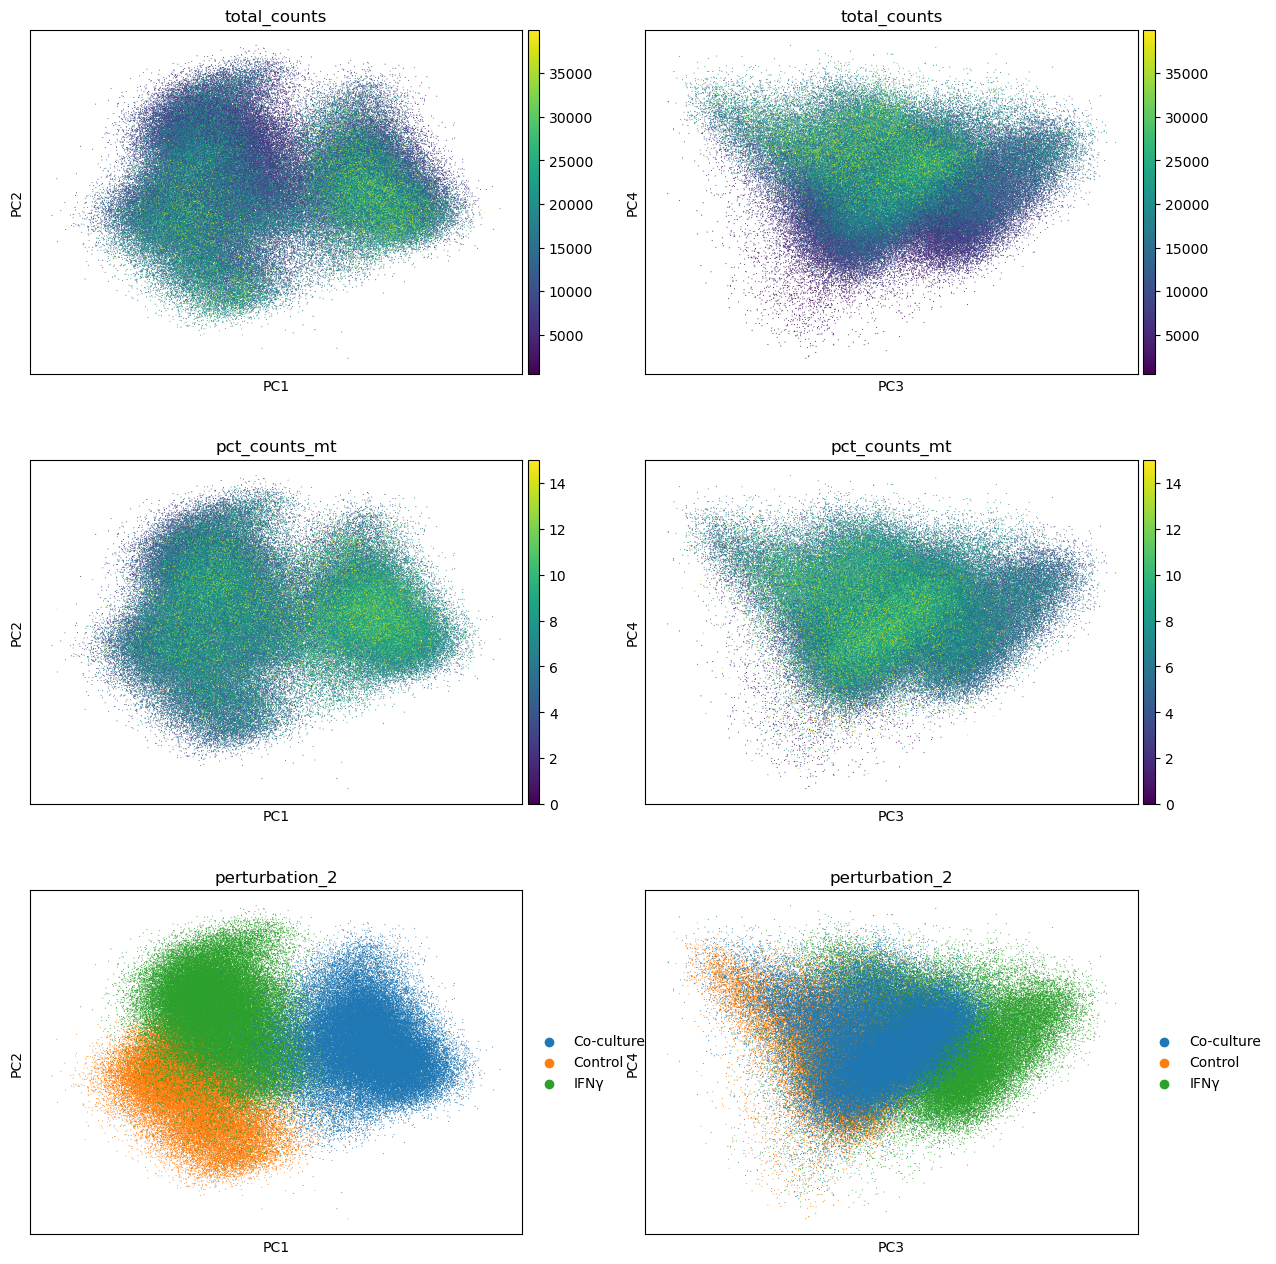

In [27]:
sc.pl.pca(
    adata,
    color=["total_counts", "total_counts", "pct_counts_mt", "pct_counts_mt", "perturbation_2", "perturbation_2"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [ ]:
# Save the data
adata_hvg_qc = adata.copy()
adata_hvg_qc = adata.write_h5ad("../data/frangieh/adata_hvg_qc")